In [1]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = '2' # Replace digit with number of desired GPU
#os.environ["JAX_PLATFORMS"] = "cpu"
os.environ["XLA_PYTHON_CLIENT_PREALLOCATE"] = "false"


%load_ext autoreload

In [2]:
# Basic Library Imports
import jax
import jax.numpy as jnp
from jax import random
from jax import vmap, jit, grad, value_and_grad

from flax import linen as nn
from flax.core import FrozenDict
import optax

import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import make_axes_locatable
import numpy as onp
import copy
import pickle
import pandas as pd

In [ ]:
%autoreload 2
import sys
sys.path.append('../..')
from jaxmix.archs import MLP, MDN, Ensemble
from jaxmix.trainers import MDNTrainer, mdn_loss_func
from jaxmix.utils import split_data
from jaxmix.data_loaders import BatchedDataset

from utils import plot_mdn_mixture_elements, plot_mdn_samples, generate_data

# Mixture Component Ablation Study

This notebook performs a hyperparameter ablation study on the number of mixture components for the sine inverse problem. We test different values of `num_mixtures` to understand how the number of mixture components affects model performance.

In [ ]:
# Configuration
possible_mixture_numbers = [i for i in range(1, 17)]

# Fixed hyperparameters
input_dim = 1
out_dim = 1
ensemble_size = 12
n_train = 1_000
n_val = 2_000
n_iter = 30_000
batch_size = 64

# Initialize random key
key = random.PRNGKey(0)

## Data Generation

Generate a consistent dataset that will be used across all experiments for fair comparison.

In [5]:
# Generate data once for all experiments
key, subkey = random.split(key)
outputs, inputs = generate_data(n_train + n_val, key=subkey)

# Split into train and validation sets
key, subkey = random.split(key)
train_data, test_data = split_data(subkey, inputs, outputs, n_train, n_val)

train_inputs, train_outputs, train_weights = train_data
test_inputs, test_outputs, test_weights = test_data

print(f"Train inputs shape: {train_inputs.shape}")
print(f"Train outputs shape: {train_outputs.shape}")
print(f"Test inputs shape: {test_inputs.shape}")
print(f"Test outputs shape: {test_outputs.shape}")

Train inputs shape: (1000, 1)
Train outputs shape: (1000, 1)
Test inputs shape: (2000, 1)
Test outputs shape: (2000, 1)


## Training Loop

Train models with different numbers of mixture components. All other hyperparameters are kept fixed to isolate the effect of the number of mixture components.

In [6]:
# Store results for each mixture number
results = {}

for num_mixtures in possible_mixture_numbers:
    print(f"\n{'='*60}")
    print(f"Training model with {num_mixtures} mixture components")
    print(f"{'='*60}\n")
    
    # Create architecture
    base_arch = MLP(features=[128, 128, 128, 128, 128])
    backbone_arch = Ensemble(base_arch, ensemble_size)
    MDN_arch = MDN(
        num_mixtures=num_mixtures, 
        num_output_dims=out_dim, 
        backbone=backbone_arch, 
        ensemble_size=ensemble_size
    )
    
    # Set up optimizer with warmup + exponential decay
    lr = optax.join_schedules(
        schedules=[
            optax.linear_schedule(
                init_value=0.0,
                end_value=1e-3,
                transition_steps=1000
            ),
            optax.exponential_decay(
                init_value=1e-3,
                transition_steps=1_000,
                decay_rate=0.9,
            ),
        ],
        boundaries=[1000]
    )
    optimizer = optax.chain(
        optax.adaptive_grad_clip(0.01),
        optax.adamw(learning_rate=lr, weight_decay=1e-1)
    )
    
    # Initialize model
    init_batch = (train_inputs, train_outputs, train_weights)
    key, subkey = random.split(key)
    model = MDNTrainer(
        MDN_arch, 
        init_batch, 
        key=subkey, 
        optimizer=optimizer, 
        normalize_inputs=True, 
        normalize_outputs=False
    )
    
    # Create data loader
    key, subkey = random.split(key)
    train_loader = BatchedDataset(train_data, subkey, batch_size=batch_size)
    
    # Train model
    model.train(train_loader, nIter=n_iter)
    
    # Store model and logs
    results[int(num_mixtures)] = {
        'model': model,
        'logs': model.logs.copy() if hasattr(model, 'logs') else None
    }
    
    print(f"Completed training for {num_mixtures} mixture components")


Training model with 1 mixture components



100%|██████████| 30000/30000 [00:22<00:00, 1358.40it/s, loss=0.9501793, grad_norm=1.6014686]  


Completed training for 1 mixture components

Training model with 2 mixture components



100%|██████████| 30000/30000 [00:21<00:00, 1395.34it/s, loss=0.4926313, grad_norm=7.7350516]  


Completed training for 2 mixture components

Training model with 3 mixture components



...

Completed training for 14 mixture components

Training model with 15 mixture components



100%|██████████| 30000/30000 [00:22<00:00, 1336.26it/s, loss=-0.20340678, grad_norm=10.454388] 


Completed training for 15 mixture components

Training model with 16 mixture components



100%|██████████| 30000/30000 [00:21<00:00, 1371.84it/s, loss=-0.080500185, grad_norm=17.599657] 

Completed training for 16 mixture components


## Evaluation

Compute negative log-likelihood (NLL) on the validation set for each model to compare performance.

In [7]:
# Compute NLL for each model on validation set
nll_results = {}

for num_mixtures in possible_mixture_numbers:
    model = results[num_mixtures]['model']
    
    # Get predictions
    pred = model.apply(model.params, test_inputs)
    mixture_logit_weights, mixture_means, mixture_variances = pred
    
    # Compute NLL per element (averaged over ensemble)
    per_element_nll = mdn_loss_func(
        mixture_logit_weights, 
        mixture_means, 
        mixture_variances, 
        test_outputs
    )
    
    # Average NLL across ensemble and samples
    mean_nll_per_ensemble_member = jnp.mean(per_element_nll, axis=(1,2)) # (ensemble_size, )
    mean_nll = jnp.mean(mean_nll_per_ensemble_member)
    std_nll = jnp.std(mean_nll_per_ensemble_member)
    
    nll_results[num_mixtures] = {
        'mean_nll': float(mean_nll),
        'std_nll': float(std_nll),
        'per_element_nll': per_element_nll
    }
    
    print(f"num_mixtures={num_mixtures:2d}: Mean NLL={mean_nll:.4f}, Std NLL={std_nll:.4f}")

num_mixtures= 1: Mean NLL=0.9796, Std NLL=0.0054
num_mixtures= 2: Mean NLL=0.6522, Std NLL=0.0311
num_mixtures= 3: Mean NLL=0.2668, Std NLL=0.0300
num_mixtures= 4: Mean NLL=0.2241, Std NLL=0.0459
num_mixtures= 5: Mean NLL=0.1618, Std NLL=0.0529
num_mixtures= 6: Mean NLL=0.1300, Std NLL=0.0359
num_mixtures= 7: Mean NLL=0.1728, Std NLL=0.0445
num_mixtures= 8: Mean NLL=0.1627, Std NLL=0.0362
num_mixtures= 9: Mean NLL=0.1476, Std NLL=0.0248
num_mixtures=10: Mean NLL=0.1412, Std NLL=0.0321
num_mixtures=11: Mean NLL=0.1251, Std NLL=0.0396
num_mixtures=12: Mean NLL=0.1384, Std NLL=0.0281
num_mixtures=13: Mean NLL=0.1608, Std NLL=0.0428
num_mixtures=14: Mean NLL=0.1571, Std NLL=0.0361
num_mixtures=15: Mean NLL=0.1734, Std NLL=0.0415
num_mixtures=16: Mean NLL=0.1491, Std NLL=0.0391


## Visualization

Visualize the ablation results to understand the relationship between the number of mixture components and model performance.

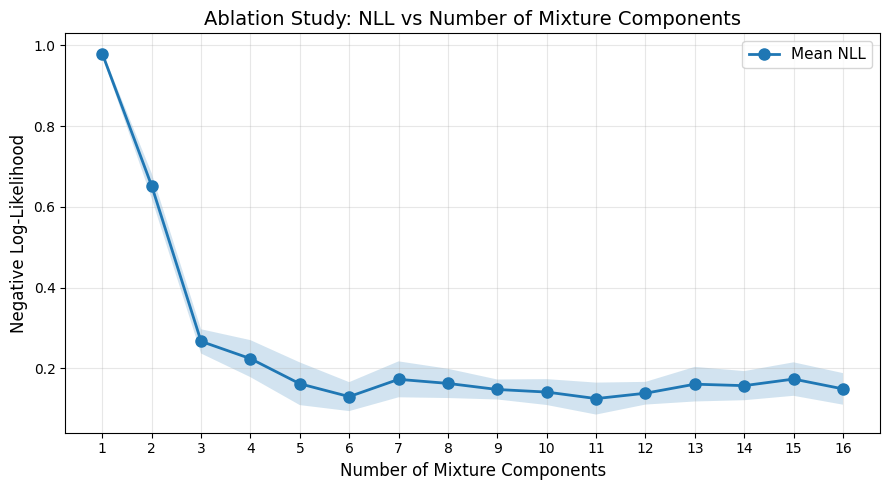

In [13]:
# Plot NLL vs number of mixture components
fig, ax = plt.subplots(figsize=(9, 5))
mixture_nums = sorted(nll_results.keys())
mean_nlls = jnp.array([nll_results[n]['mean_nll'] for n in mixture_nums])
std_nlls = jnp.array([nll_results[n]['std_nll'] for n in mixture_nums])

ax.plot(mixture_nums, mean_nlls, 'o-', label='Mean NLL', linewidth=2, markersize=8)
ax.fill_between(mixture_nums, mean_nlls - std_nlls, mean_nlls + std_nlls, alpha=0.2)
ax.set_xlabel('Number of Mixture Components', fontsize=12)
ax.set_ylabel('Negative Log-Likelihood', fontsize=12)
ax.set_title('Ablation Study: NLL vs Number of Mixture Components', fontsize=14)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
#ax.set_xscale('log', base=2)
ax.set_xticks(mixture_nums)
ax.set_xticklabels([str(n) for n in mixture_nums])
plt.tight_layout()
plt.show()

In [9]:
# Create summary table
summary_data = {
    'num_mixtures': mixture_nums,
    'mean_nll': mean_nlls,
    'std_nll': std_nlls
}
df_summary = pd.DataFrame(summary_data)
print("\nSummary Table:")
print(df_summary.to_string(index=False))


Summary Table:
 num_mixtures  mean_nll  std_nll
            1  0.979640 0.005408
            2  0.652180 0.031132
            3  0.266843 0.030026
            4  0.224076 0.045853
            5  0.161834 0.052885
            6  0.129953 0.035875
            7  0.172796 0.044503
            8  0.162689 0.036217
            9  0.147617 0.024755
           10  0.141249 0.032058
           11  0.125085 0.039596
           12  0.138369 0.028121
           13  0.160775 0.042837
           14  0.157124 0.036087
           15  0.173442 0.041476
           16  0.149076 0.039102


## Sample Predictions

Visualize sample predictions for different numbers of mixture components to see how the model behavior changes.

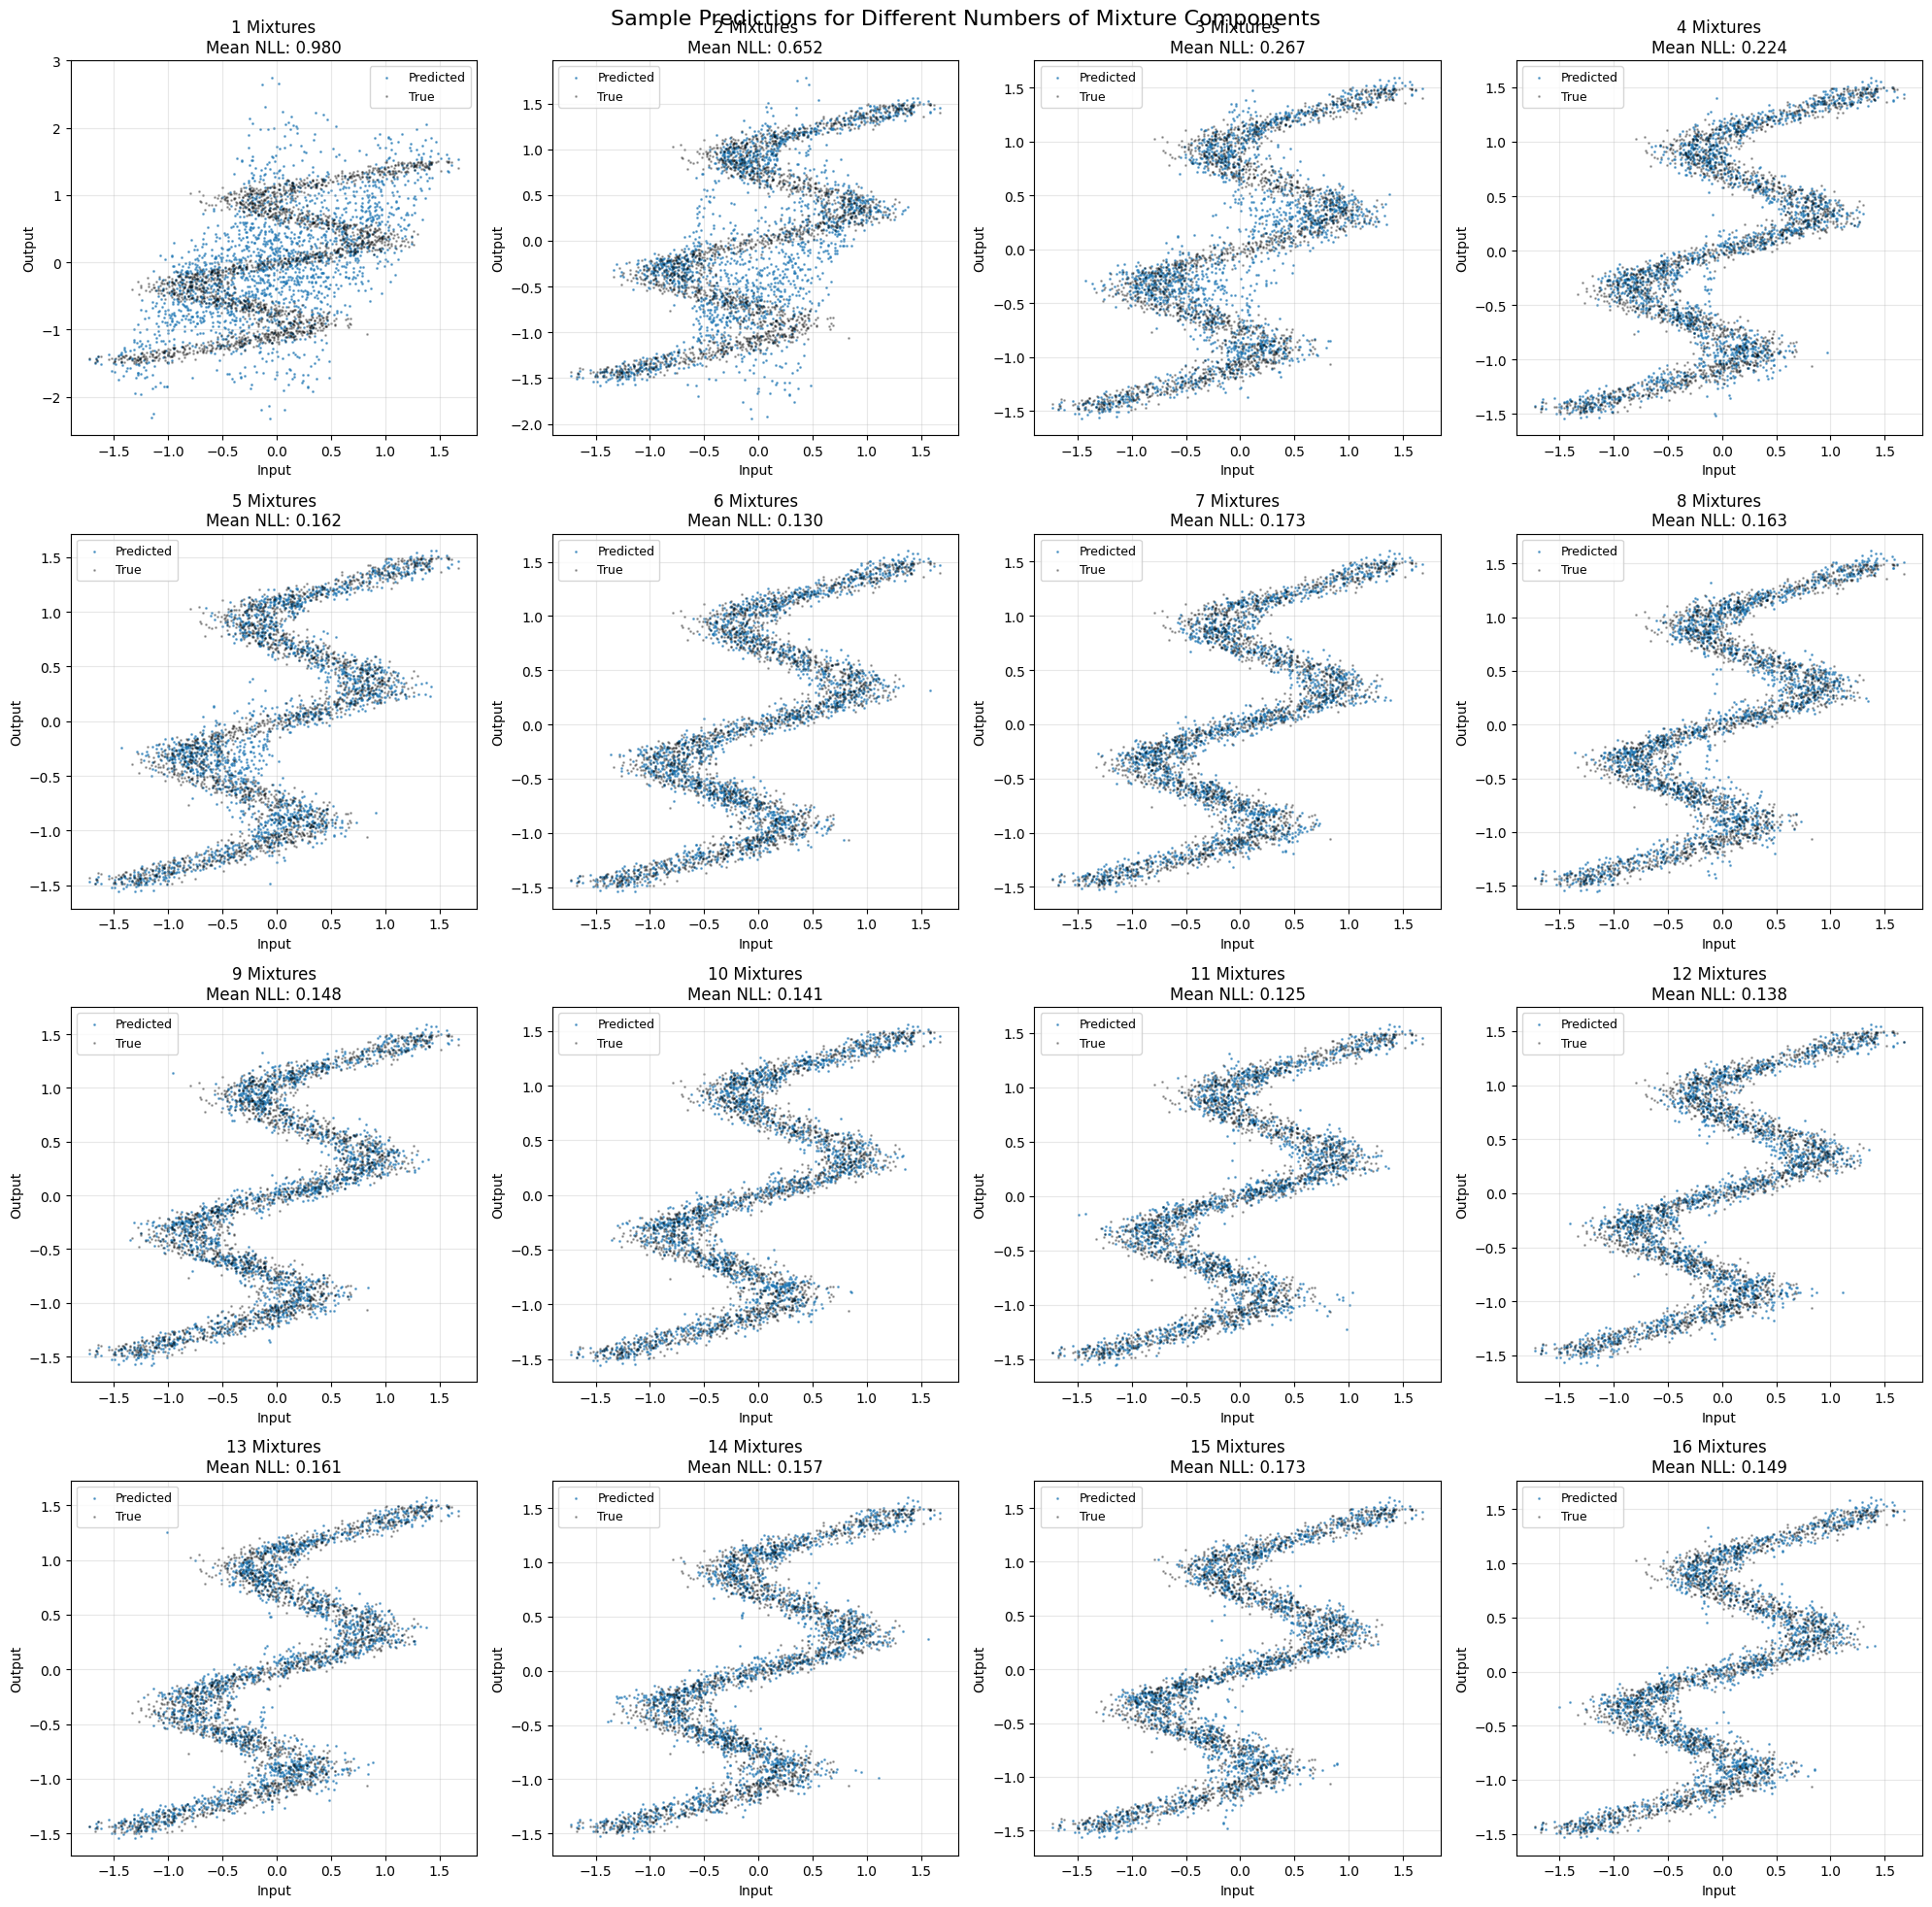

In [10]:
# Plot sample predictions for selected mixture numbers
selected_mixtures =  possible_mixture_numbers
num_cols = 4
num_rows = (len(selected_mixtures) + num_cols - 1) // num_cols

fig, axes = plt.subplots(num_rows, num_cols, figsize=(5 * num_cols, 5 * num_rows))
axes = axes.flatten()

for idx, num_mixtures in enumerate(selected_mixtures):
    if num_mixtures not in results:
        continue
        
    model = results[num_mixtures]['model']
    
    # Get predictions
    pred = model.apply(model.params, test_inputs)
    mixture_logit_weights, mixture_means, mixture_variances = pred
    
    # Sample from mixture (for all ensemble members, then use first)
    samples = model.sample_from_mixture(
        random.PRNGKey(23), 
        mixture_logit_weights, 
        mixture_means, 
        mixture_variances
    )
    
    # Use first ensemble member for visualization
    samples_first = samples[0]
    
    # Compute NLL for all ensemble members
    per_element_nll = mdn_loss_func(
        mixture_logit_weights, 
        mixture_means, 
        mixture_variances, 
        test_outputs
    )
    # Average NLL across ensemble
    mean_nll = jnp.mean(per_element_nll)
    
    axes[idx].scatter(test_inputs.squeeze(), samples_first.squeeze(), s=1, label='Predicted', alpha=0.6)
    axes[idx].scatter(test_inputs.squeeze(), test_outputs.squeeze(), s=1, alpha=0.3, label='True', c='black')
    axes[idx].set_title(f'{num_mixtures} Mixtures\nMean NLL: {mean_nll:.3f}', fontsize=12)
    axes[idx].set_xlabel('Input', fontsize=10)
    axes[idx].set_ylabel('Output', fontsize=10)
    axes[idx].legend(fontsize=9)
    axes[idx].grid(True, alpha=0.3)

# Hide unused subplots
for idx in range(len(selected_mixtures), len(axes)):
    axes[idx].set_visible(False)

fig.suptitle('Sample Predictions for Different Numbers of Mixture Components', fontsize=16)
plt.tight_layout()
plt.show()

## Mixture Element Visualization

Visualize the mixture elements for selected models to understand how the mixture components are being used.


Mixture Elements for 1 Mixture Components



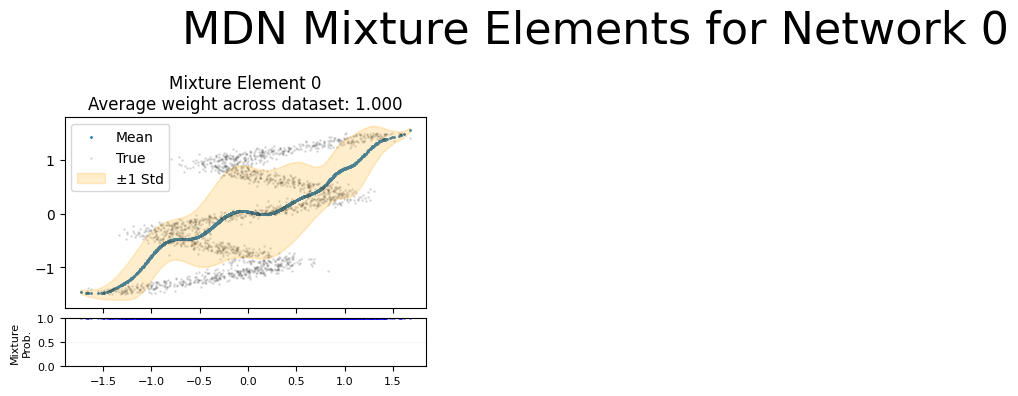


Mixture Elements for 2 Mixture Components



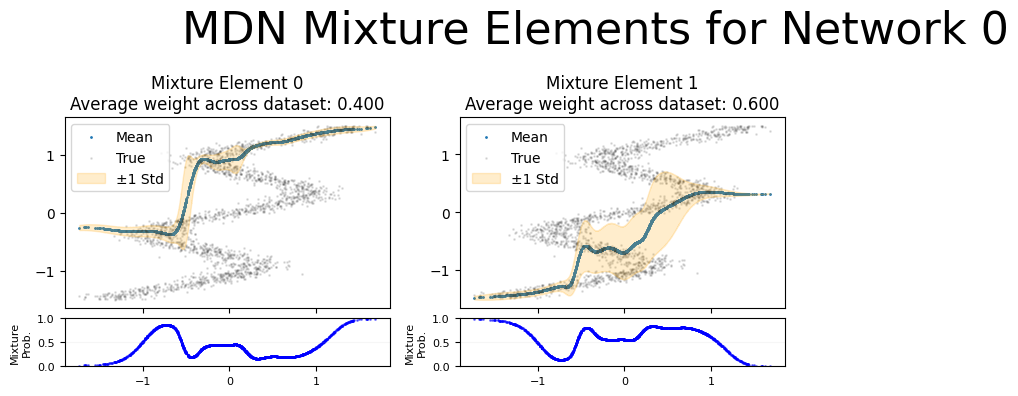


Mixture Elements for 3 Mixture Components



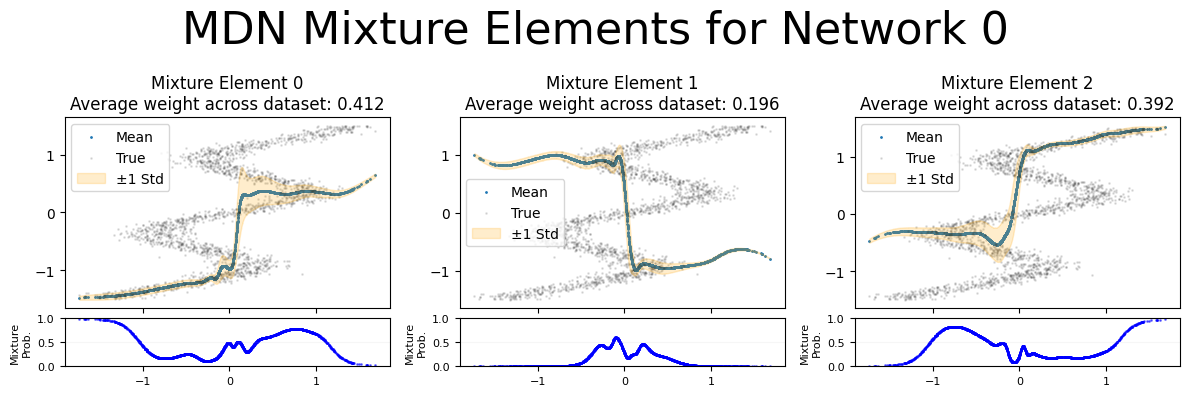


Mixture Elements for 4 Mixture Components



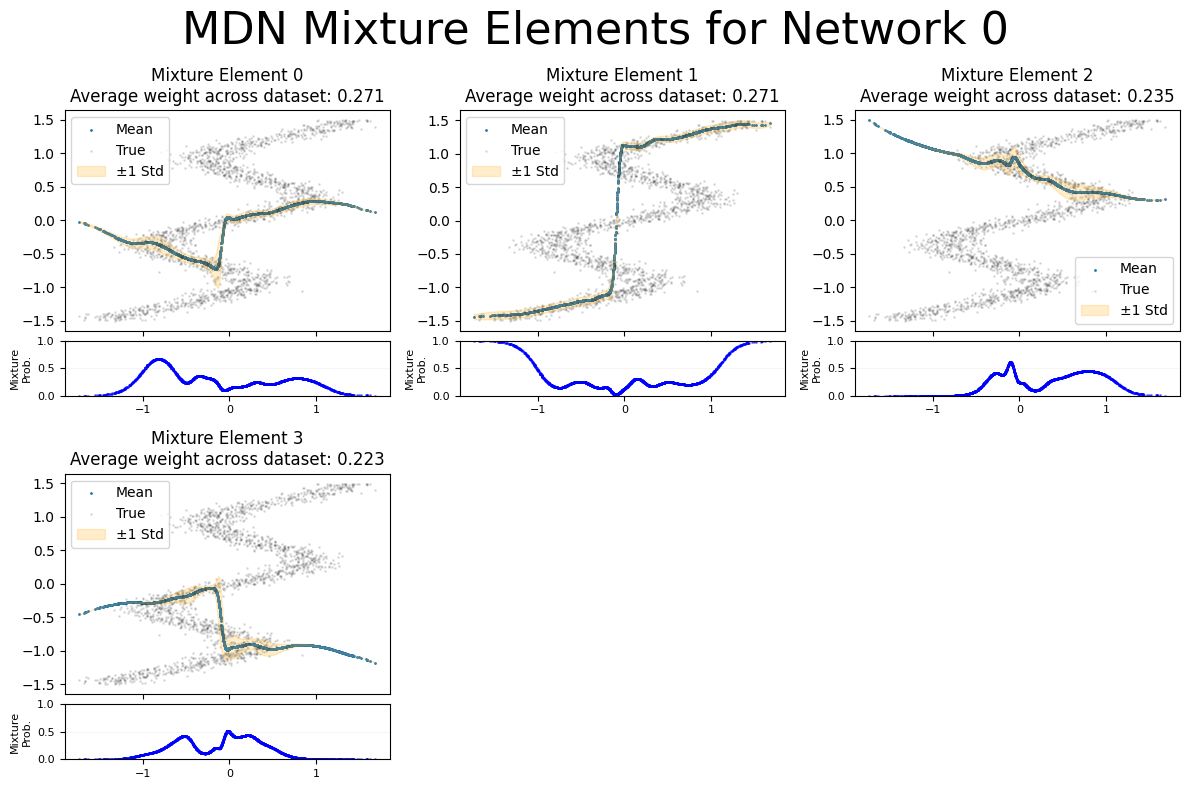


Mixture Elements for 8 Mixture Components



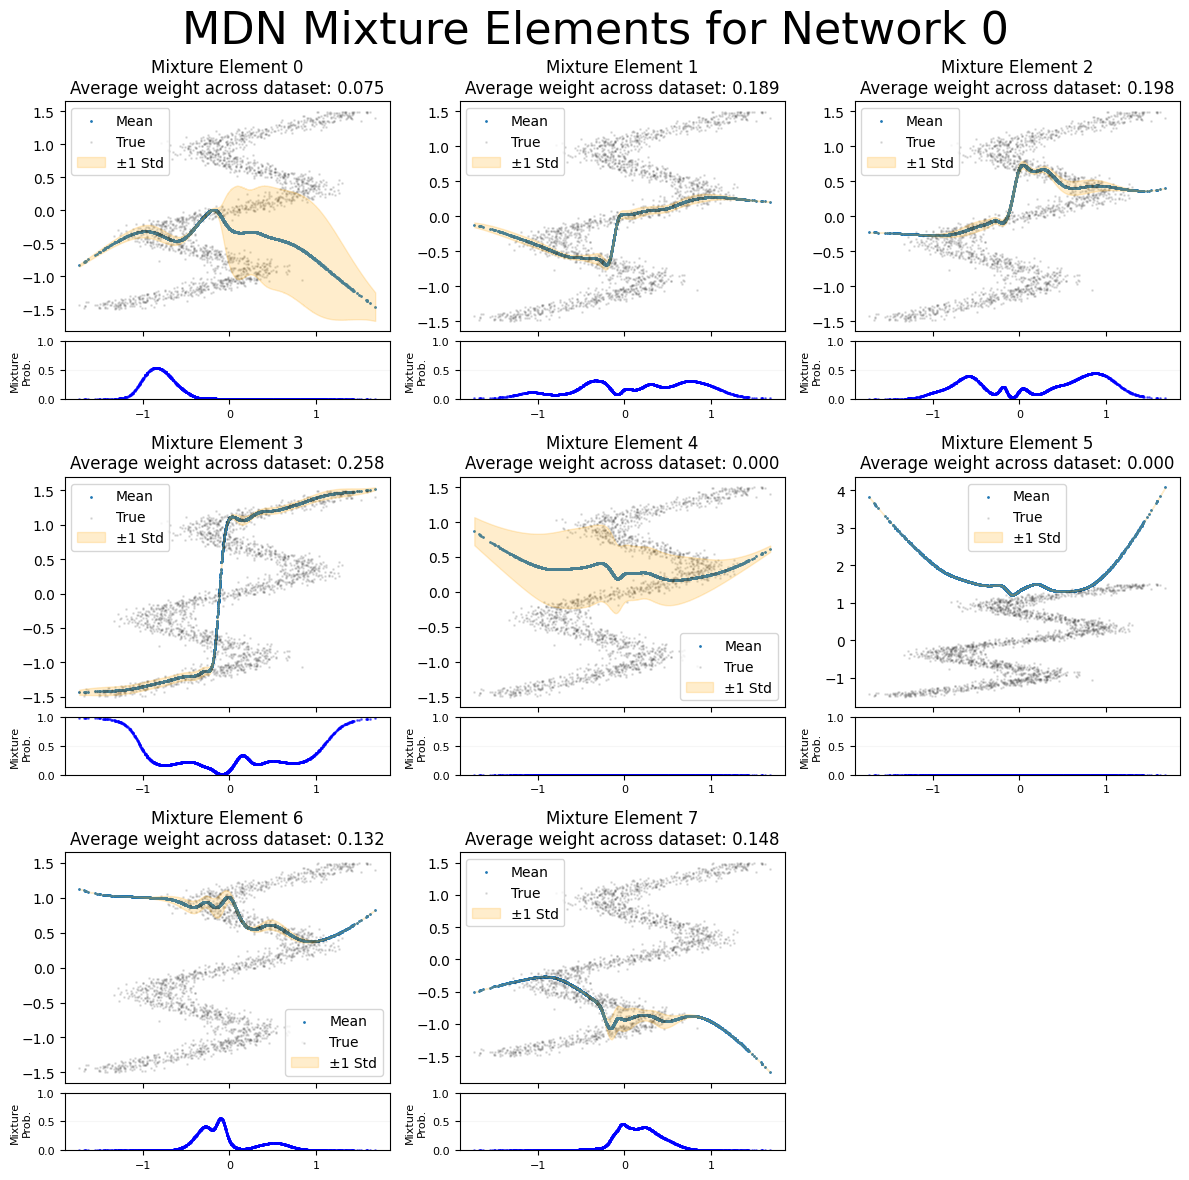


Mixture Elements for 16 Mixture Components



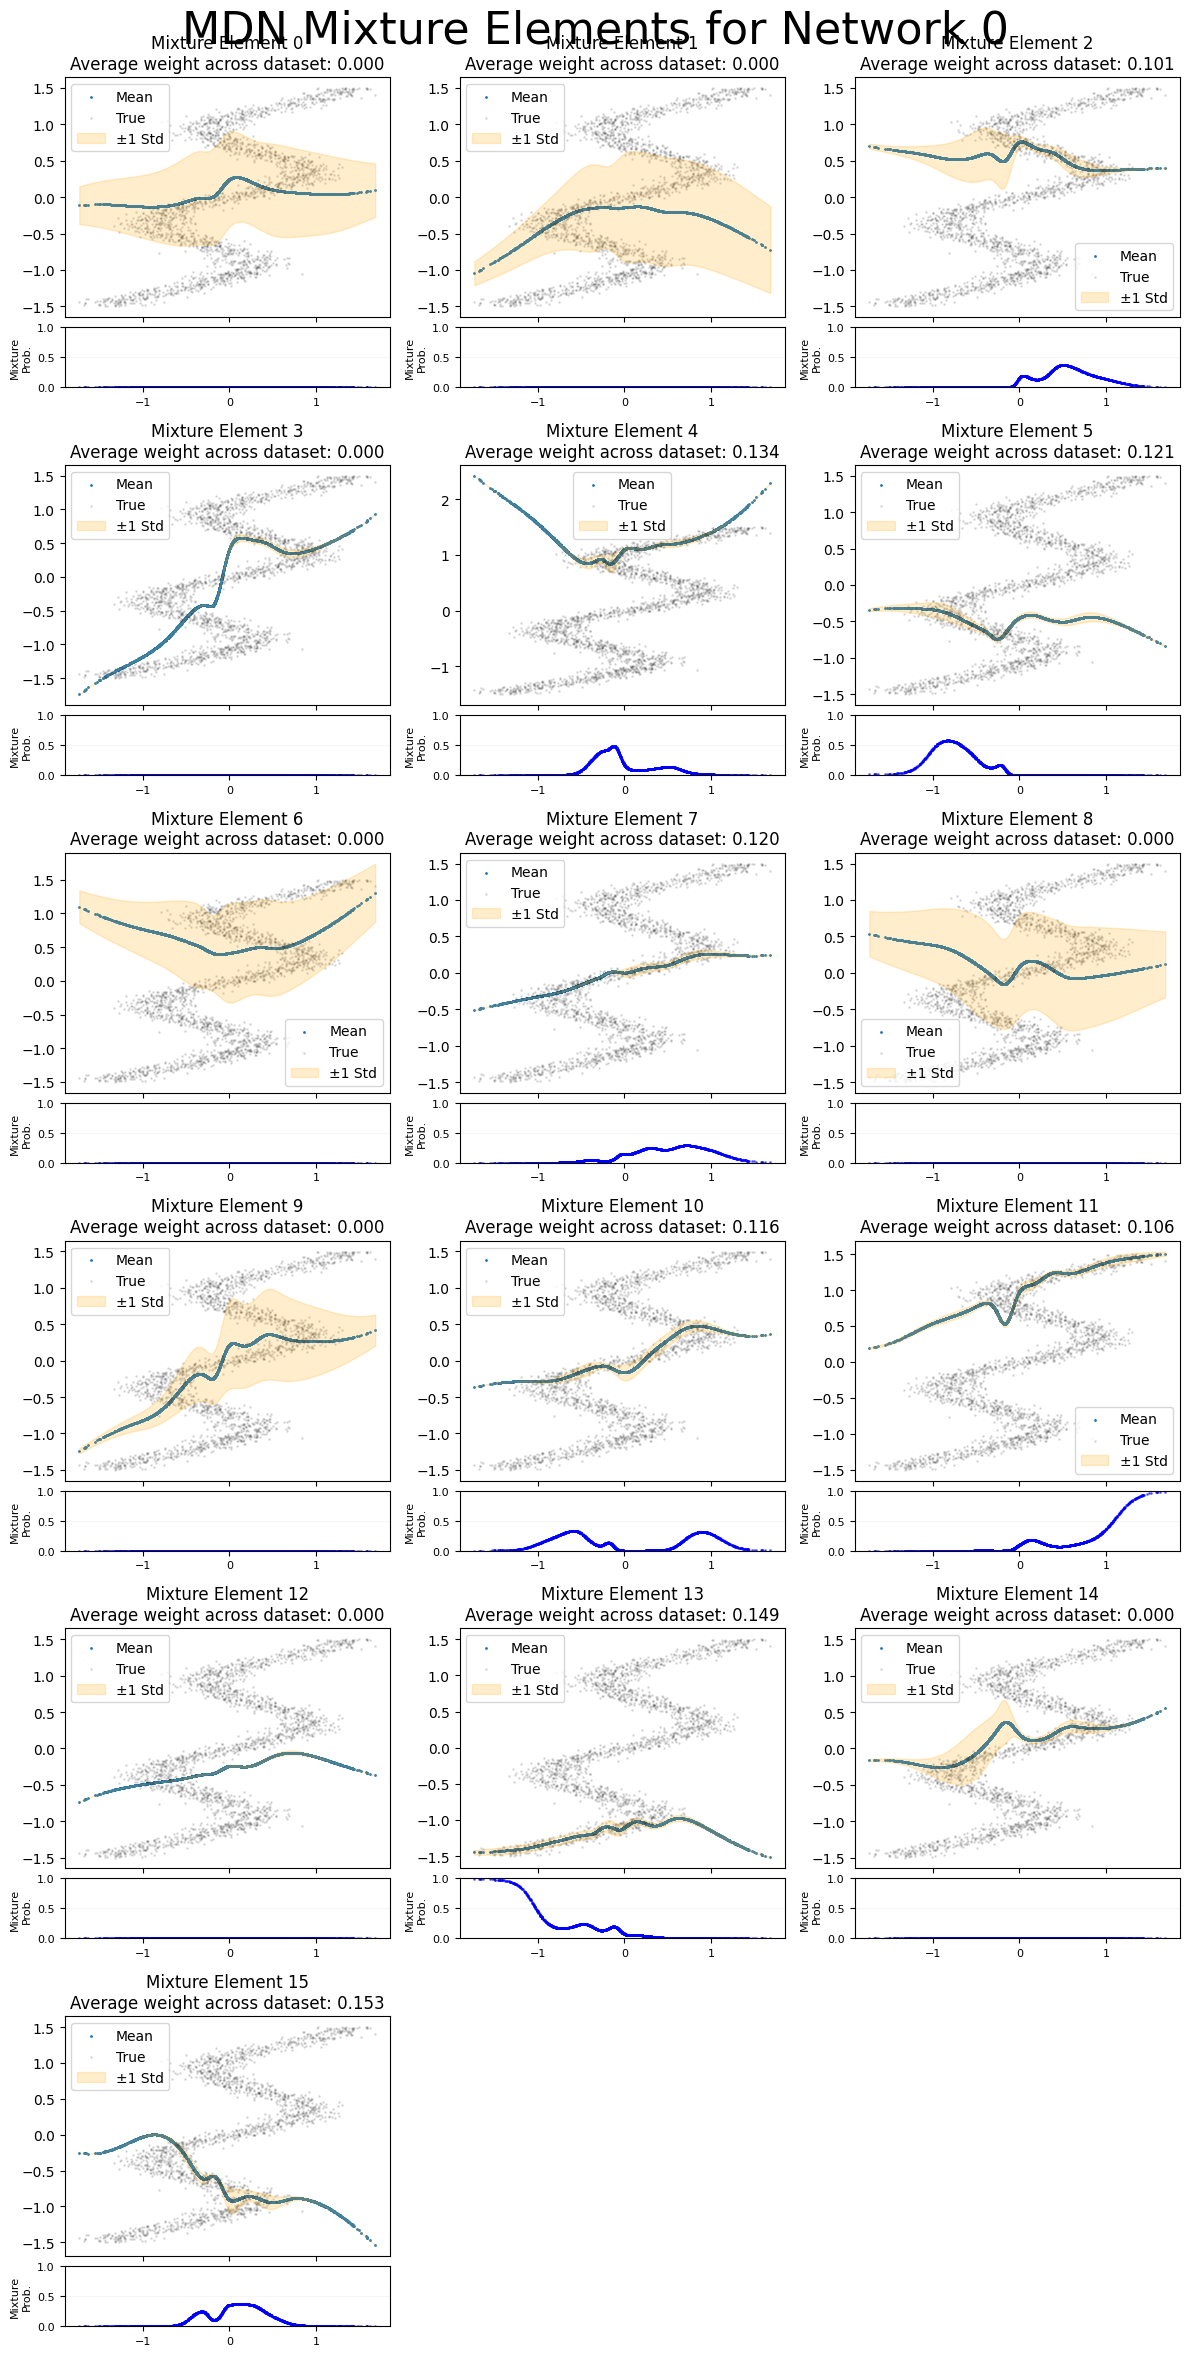

In [11]:
# Visualize mixture elements for (potentially) a few selected models
selected_for_viz = [1, 2, 3, 4, 8, 16]

for num_mixtures in selected_for_viz:
    if num_mixtures not in results:
        continue
    
    print(f"\n{'='*60}")
    print(f"Mixture Elements for {num_mixtures} Mixture Components")
    print(f"{'='*60}\n")
    
    model = results[num_mixtures]['model']
    # Use first ensemble member for visualization
    plot_mdn_mixture_elements(model, test_inputs, test_outputs, net_id=0, num_cols=3)